# PROJECT 2 EcoVault Face Unlock for Field Research Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve,
                             f1_score, precision_score,
                             recall_score, confusion_matrix)
from sklearn.preprocessing import normalize
from sklearn.utils.class_weight import compute_class_weight


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

import os, pathlib, shutil

### DATA LOADING

In [2]:
lfw = fetch_lfw_people(
    min_faces_per_person=5,
    resize=0.5,
    color=True,
    download_if_missing=True
)

images = lfw.images      
targets = lfw.target
names = lfw.target_names

print(f"Total images: {len(images)}")
print(f"Total identities: {len(names)}")
print(f"Image shape: {images.shape[1:]}")
print(f"Pixel range: {images.min():.2f} to {images.max():.2f}")

Total images: 5985
Total identities: 423
Image shape: (62, 47, 3)
Pixel range: 0.00 to 1.00


I loaded LFW with min_faces_per_person=5, which gave me 5,985 images across 423 identities. I did that because EcoVault needs a bigger and more realistic impostor pool. If I only keep people with a lot of images, the negative class gets too small and the task stops looking like a real verification problem. The images are already scaled between 0 and 1, so I leave them like that at first and only change the scaling later when a specific model needs something different.

### EDA (CLASS SETUP AND DISTRIBUTION)

Enrolled user: George W Bush
Total images: 5985
Positives (George W Bush): 530
Negatives (everyone else): 5455
Total identities: 423
Positive rate: 8.86%



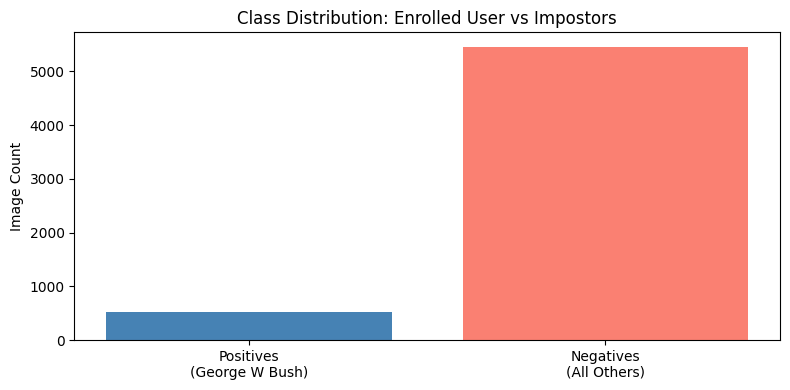

In [3]:
enrolled_name = 'George W Bush'
bush_idx = list(names).index(enrolled_name)
labels = (targets == bush_idx).astype(int)

print(f"Enrolled user: {enrolled_name}")
print(f"Total images: {len(labels)}")
print(f"Positives ({enrolled_name}): {labels.sum()}")
print(f"Negatives (everyone else): {(labels == 0).sum()}")
print(f"Total identities: {len(names)}")
print(f"Positive rate: {labels.mean():.2%}\n")

plt.figure(figsize=(8, 4))
plt.bar(
    [f'Positives\n({enrolled_name})', 'Negatives\n(All Others)'],
    [labels.sum(), (labels == 0).sum()],
    color=['steelblue', 'salmon']
)
plt.title('Class Distribution: Enrolled User vs Impostors')
plt.ylabel('Image Count')
plt.tight_layout()
plt.show()

I set this up as a one-vs-all verification task. George W. Bush is the enrolled user, so his images are the positive class, and everyone else is treated as an impostor. That gives me 530 positive images and 5,455 negative images, so the dataset is pretty imbalanced, which is actually what I want because a real system would usually see way more non-enrolled people than enrolled ones. I switched to George W. Bush because the earlier enrolled user did not have enough images, and that made the training and evaluation way too unstable.

### FACIAL VERIFICATION VISUALIZATION

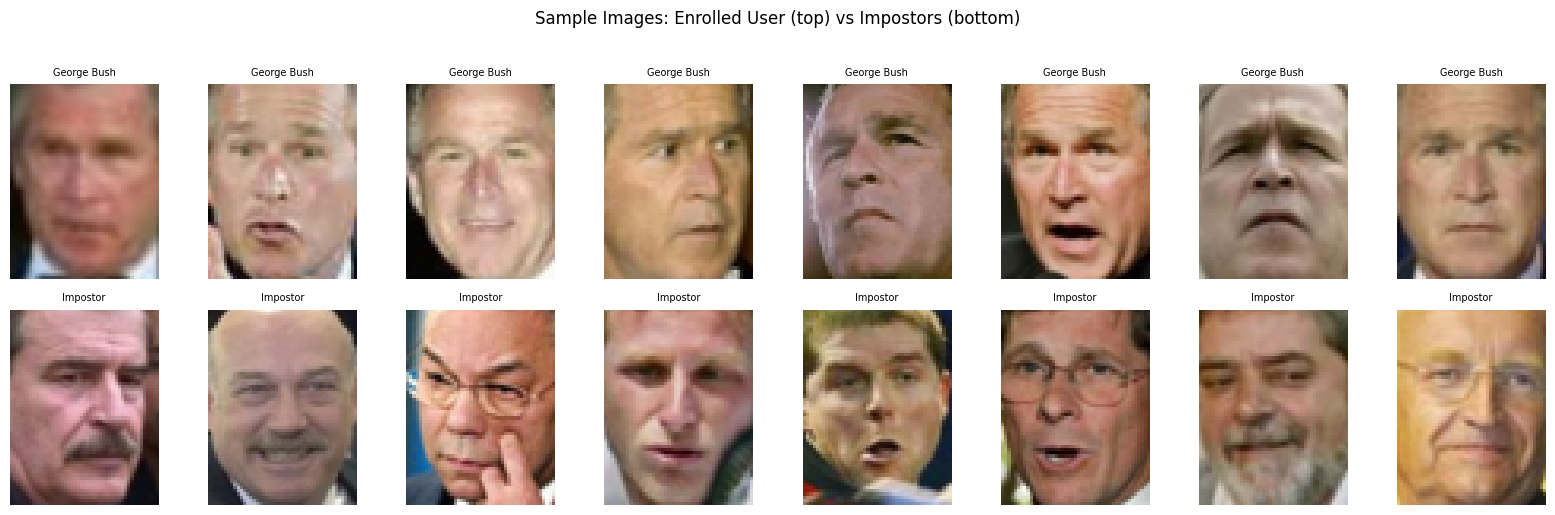

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

bush_imgs = images[targets == bush_idx]
other_imgs  = images[targets != bush_idx]

for i, ax in enumerate(axes[0]):
    ax.imshow(bush_imgs[i])
    ax.set_title('George Bush', fontsize=7)
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    ax.imshow(other_imgs[i * 30])
    ax.set_title('Impostor', fontsize=7)
    ax.axis('off')

plt.suptitle('Sample Images: Enrolled User (top) vs Impostors (bottom)', y=1.02)
plt.tight_layout()
plt.show()

Before training anything, I wanted to actually look at the faces. The George W. Bush images already show changes in lighting, expression, and pose, which is useful because the model needs to handle some variation even within the enrolled user. The impostor images are clearly diverse too, so this is not just the model learning to separate one face from a few very similar negatives. The bigger issue is that the images are only 62 by 47, so there is not much fine detail for the models to work with.

### CONDITION OF PHOTOS ANALYSIS

Total enrolled images:   530
Bright images:           265  (50%)
Dark images:             265   (50%)
High-contrast images:    265 (50%)
Low-contrast images:     265 (50%)

Mean brightness: 0.512 | Std: 0.065
Mean contrast:   0.194 | Std: 0.029


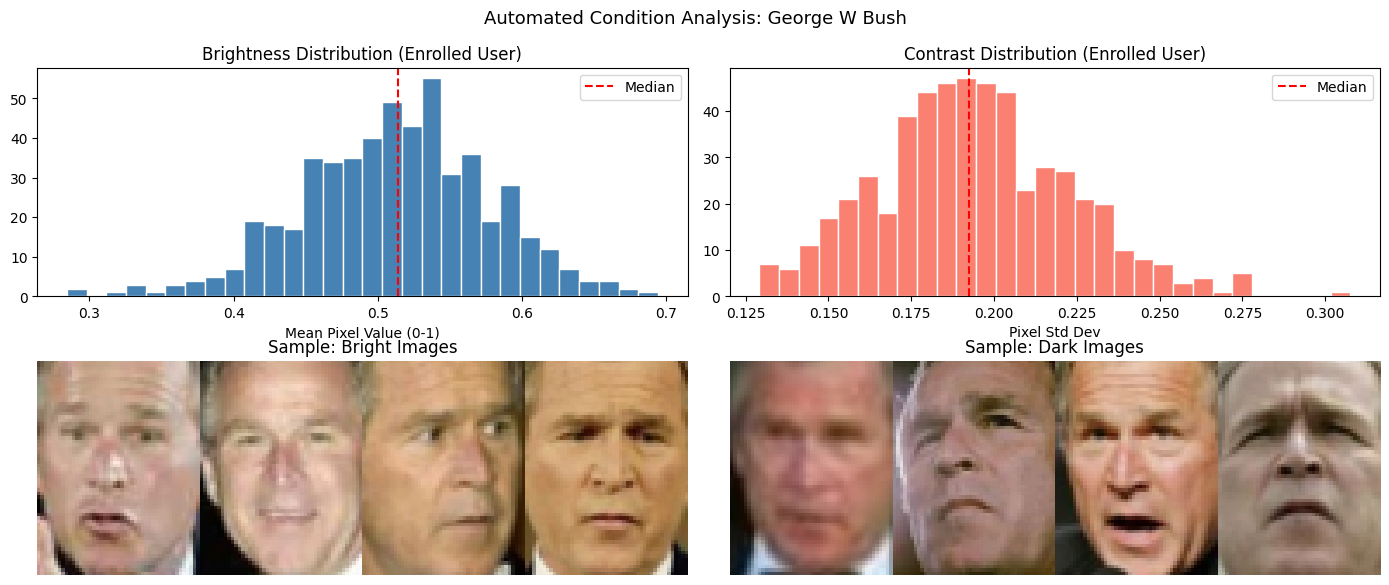

In [5]:
# Automated brightness and contrast analysis on enrolled user images
enrolled_imgs = images[targets == bush_idx]

brightness = enrolled_imgs.mean(axis=(1, 2, 3))   
contrast   = enrolled_imgs.std(axis=(1, 2, 3))    

# Classify conditions
bright_mask  = brightness >= np.median(brightness)
dark_mask    = ~bright_mask
hicontrast_mask = contrast >= np.median(contrast)
locontrast_mask = ~hicontrast_mask

print(f"Total enrolled images:   {len(enrolled_imgs)}")
print(f"Bright images:           {bright_mask.sum()}  ({bright_mask.mean():.0%})")
print(f"Dark images:             {dark_mask.sum()}   ({dark_mask.mean():.0%})")
print(f"High-contrast images:    {hicontrast_mask.sum()} ({hicontrast_mask.mean():.0%})")
print(f"Low-contrast images:     {locontrast_mask.sum()} ({locontrast_mask.mean():.0%})")
print(f"\nMean brightness: {brightness.mean():.3f} | Std: {brightness.std():.3f}")
print(f"Mean contrast:   {contrast.mean():.3f} | Std: {contrast.std():.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 6))

# Brightness distribution
axes[0, 0].hist(brightness, bins=30, color='steelblue', edgecolor='white')
axes[0, 0].axvline(np.median(brightness), color='red', linestyle='--', label='Median')
axes[0, 0].set_title('Brightness Distribution (Enrolled User)')
axes[0, 0].set_xlabel('Mean Pixel Value (0-1)')
axes[0, 0].legend()

# Contrast distribution
axes[0, 1].hist(contrast, bins=30, color='salmon', edgecolor='white')
axes[0, 1].axvline(np.median(contrast), color='red', linestyle='--', label='Median')
axes[0, 1].set_title('Contrast Distribution (Enrolled User)')
axes[0, 1].set_xlabel('Pixel Std Dev')
axes[0, 1].legend()

# Sample bright images
bright_imgs = enrolled_imgs[bright_mask]
for i, ax in enumerate(axes[1, :]):
    if i == 0:
        sample = bright_imgs[:4]
        ax.set_title('Sample: Bright Images')
    else:
        sample = enrolled_imgs[dark_mask][:4]
        ax.set_title('Sample: Dark Images')
    ax.axis('off')
    combined = np.concatenate(sample[:4], axis=1)
    ax.imshow(combined)

plt.suptitle(f'Automated Condition Analysis: {enrolled_name}', fontsize=13)
plt.tight_layout()
plt.show()

enrolled_brightness = brightness
enrolled_contrast   = contrast

Instead of manually tagging hundreds of images by lighting condition, I used mean pixel value as a brightness proxy and standard deviation as a contrast proxy. The median split gave me 265 bright and 265 dark enrolled images, plus the same split for contrast, with mean brightness 0.512 and mean contrast 0.194. It is not perfect, but it gives me a clean and repeatable way to test whether performance changes when the images get darker or flatter.

### DATA SPLITTING (IDENTITY-LEVEL FOR NEGATIVES)

In [6]:
np.random.seed(42)

neg_identity_indices = [i for i in range(len(names)) if i != bush_idx]
np.random.shuffle(neg_identity_indices)

split_point       = int(0.75 * len(neg_identity_indices))
train_val_neg_ids = neg_identity_indices[:split_point]
test_neg_ids      = neg_identity_indices[split_point:]

print(f"Train/val negative identities: {len(train_val_neg_ids)}")
print(f"Test-only negative identities: {len(test_neg_ids)}")

bush_imgs_all   = images[targets == bush_idx]
bush_labels_all = np.ones(len(bush_imgs_all), dtype=int)

trainval_neg_mask = np.isin(targets, train_val_neg_ids)
test_neg_mask     = np.isin(targets, test_neg_ids)

trainval_neg_imgs   = images[trainval_neg_mask]
trainval_neg_labels = np.zeros(len(trainval_neg_imgs), dtype=int)
test_neg_imgs       = images[test_neg_mask]
test_neg_labels     = np.zeros(len(test_neg_imgs), dtype=int)

# Positives: 60% train, 20% val, 20% test
X_c_tr, X_c_tmp, y_c_tr, y_c_tmp = train_test_split(
    bush_imgs_all, bush_labels_all, test_size=0.4, random_state=42)
X_c_val, X_c_test, y_c_val, y_c_test = train_test_split(
    X_c_tmp, y_c_tmp, test_size=0.5, random_state=42)

# Negatives
X_n_tr, X_n_val, y_n_tr, y_n_val = train_test_split(
    trainval_neg_imgs, trainval_neg_labels, test_size=0.25, random_state=42)

X_train = np.concatenate([X_c_tr,   X_n_tr])
y_train = np.concatenate([y_c_tr,   y_n_tr])
X_val   = np.concatenate([X_c_val,  X_n_val])
y_val   = np.concatenate([y_c_val,  y_n_val])
X_test  = np.concatenate([X_c_test, test_neg_imgs])
y_test  = np.concatenate([y_c_test, test_neg_labels])

print(f"\nTrain: {X_train.shape} and the Positive rate: {y_train.mean():.2%}")
print(f"Val:   {X_val.shape}  and the Positive rate: {y_val.mean():.2%}")
print(f"Test:  {X_test.shape} and the Positive rate: {y_test.mean():.2%}")
print(f"\nTrain positives: {y_train.sum()} and the negatives: {(y_train==0).sum()}")
print(f"Val   positives: {y_val.sum()} and the negatives: {(y_val==0).sum()}")
print(f"Test  positives: {y_test.sum()} and the negatives: {(y_test==0).sum()}")

Train/val negative identities: 316
Test-only negative identities: 106

Train: (3526, 62, 47, 3) and the Positive rate: 9.02%
Val:   (1176, 62, 47, 3)  and the Positive rate: 9.01%
Test:  (1283, 62, 47, 3) and the Positive rate: 8.26%

Train positives: 318 and the negatives: 3208
Val   positives: 106 and the negatives: 1070
Test  positives: 106 and the negatives: 1177


The most important part here is that I split the negative class by identity, not just by image. I put 316 non-Bush identities into the train and validation pool and held out 106 identities for test only, which means the model gets evaluated on impostors it has never seen before. That matters a lot because in the actual EcoVault use case the system would need to reject random people, not just the same identities it already saw during training. The final split is 3,526 training images, 1,176 validation images, and 1,283 test images, with 318, 106, and 106 positives in those sets.


### Test Set Condition Labels 

In [7]:
test_brightness = X_test.mean(axis=(1, 2, 3))
test_contrast   = X_test.std(axis=(1, 2, 3))

test_bright_mask = test_brightness >= np.median(test_brightness)
test_dark_mask   = ~test_bright_mask

print(f"Bright test images: {test_bright_mask.sum()}")
print(f"Dark test images: {test_dark_mask.sum()}")
print(f"Test positives for bright picture: {(y_test[test_bright_mask] == 1).sum()}")
print(f"Test positives for dark picture: {(y_test[test_dark_mask] == 1).sum()}")


Bright test images: 642
Dark test images: 641
Test positives for bright picture: 70
Test positives for dark picture: 36


I created the brightness labels for the test set before training so the condition labels are fully separate from the model outputs. The test set ends up almost perfectly split between bright and dark images, 642 versus 641, although the positive class is not evenly split because there are 70 bright positives and 36 dark positives. So I can still use the condition breakdown, but I have to be a little careful not to overstate the dark-condition conclusions since that subset is smaller.

### DATA PREP FOR VGG16 MODEL AND CLASS WEIGHTS

In [8]:
IMG_SIZE_FT = (180, 180)

def resize_to_180(X):
    return tf.image.resize(X * 255.0, IMG_SIZE_FT).numpy()

X_train_180 = resize_to_180(X_train)
X_val_180   = resize_to_180(X_val)
X_test_180  = resize_to_180(X_test)

print(f"Resized shape: {X_train_180.shape}")
print(f"Pixel range after resize: {X_train_180.min():.0f} to {X_train_180.max():.0f}")

# Class weights to help compensate for 42 positives vs 3499 negatives
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}

print(f"\nClass weights: {class_weight_dict}")
print(f"Positive class gets ~{class_weight_dict[1]/class_weight_dict[0]:.0f}x more weight than negative")

Resized shape: (3526, 180, 180, 3)
Pixel range after resize: 0 to 255

Class weights: {0: 0.5495635910224439, 1: 5.544025157232705}
Positive class gets ~10x more weight than negative


For the VGG16 pipeline, I resized the images to 180 by 180 and scaled them back to the 0 to 255 range because that is what VGG16 expects. I also used balanced class weights, which ended up giving the positive class about 10 times more weight than the negative class during training. That is important here because otherwise the model could mostly predict impostor and still look good on accuracy just because the dataset is so imbalanced.

### VGG16 FROZEN EMBEDDINGS AND COSINE SIMILARITY

Extracting embeddings: train
Extracting embedding: val
Extracting embeddings: test

Embedding dim: 25088

Score range:           0.333 to 0.809
Mean — George bush:    0.667
Mean — Impostors:      0.608
Score gap:             0.060


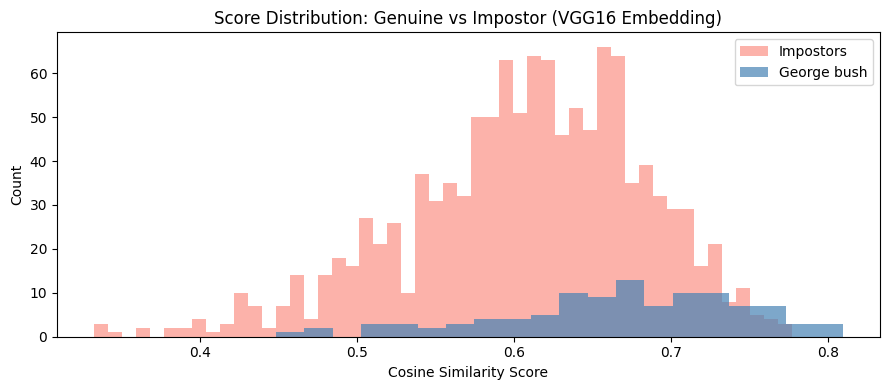

In [9]:
IMG_SIZE_EMB = (224, 224)

def prepare_for_vgg_emb(imgs):
    resized = tf.image.resize(imgs * 255.0, IMG_SIZE_EMB).numpy()
    return preprocess_input(resized)

vgg_feat = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg_feat.trainable = False

def get_embeddings(X, batch_size=32):
    out = []
    for i in range(0, len(X), batch_size):
        batch = prepare_for_vgg_emb(X[i:i+batch_size])
        feat  = vgg_feat.predict(batch, verbose=0)
        out.append(feat.reshape(len(batch), -1))
    return np.concatenate(out)

print("Extracting embeddings: train")
train_emb = normalize(get_embeddings(X_train))
print("Extracting embedding: val")
val_emb   = normalize(get_embeddings(X_val))
print("Extracting embeddings: test")
test_emb  = normalize(get_embeddings(X_test))

print(f"\nEmbedding dim: {train_emb.shape[1]}")

# Enrolled template = mean of training positives
enrolled_emb = normalize(train_emb[y_train == 1].mean(axis=0, keepdims=True))

# Cosine similarity for all test images
test_scores_emb = (test_emb @ enrolled_emb.T).flatten()

pos_scores = test_scores_emb[y_test == 1]
neg_scores = test_scores_emb[y_test == 0]

print(f"\nScore range:           {test_scores_emb.min():.3f} to {test_scores_emb.max():.3f}")
print(f"Mean — George bush:    {pos_scores.mean():.3f}")
print(f"Mean — Impostors:      {neg_scores.mean():.3f}")
print(f"Score gap:             {pos_scores.mean() - neg_scores.mean():.3f}")

plt.figure(figsize=(9, 4))
plt.hist(neg_scores, bins=50, alpha=0.6, label='Impostors', color='salmon')
plt.hist(pos_scores, bins=20, alpha=0.7, label='George bush', color='steelblue')
plt.xlabel('Cosine Similarity Score')
plt.ylabel('Count')
plt.title('Score Distribution: Genuine vs Impostor (VGG16 Embedding)')
plt.legend()
plt.tight_layout()
plt.show()


This first baseline uses VGG16 as a frozen feature extractor. I turn each image into a 25,088-dimensional embedding, average the positive training embeddings into one enrolled template, and then compare test faces to that template using cosine similarity. The score range looks decent at first, but the actual separation is weak. The mean genuine score is 0.667 and the mean impostor score is 0.608, so the gap is only about 0.06. That tells me there is some signal there, but not nearly enough to support a strong verification threshold.

### ROC, AUC, EER

Approach 1: VGG16 Frozen Embeddings
AUC: 0.7174
EER: 33.80%
TPR @ FAR ≤ 0.5%: 8.49%


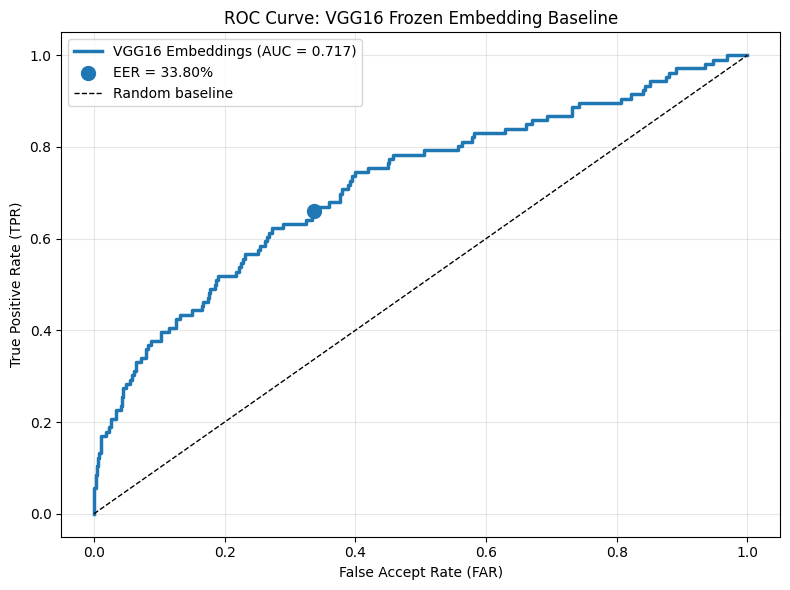

In [10]:
fpr_emb, tpr_emb, thresh_emb = roc_curve(y_test, test_scores_emb)
auc_emb = roc_auc_score(y_test, test_scores_emb)

fnr_emb     = 1 - tpr_emb
eer_idx_emb = np.argmin(np.abs(fpr_emb - fnr_emb))
eer_emb     = (fpr_emb[eer_idx_emb] + fnr_emb[eer_idx_emb]) / 2

far_mask_emb    = fpr_emb <= 0.005
tpr_at_far_emb  = tpr_emb[far_mask_emb].max() if far_mask_emb.any() else 0.0

print("Approach 1: VGG16 Frozen Embeddings")
print(f"AUC: {auc_emb:.4f}")
print(f"EER: {eer_emb:.2%}")
print(f"TPR @ FAR ≤ 0.5%: {tpr_at_far_emb:.2%}")

plt.figure(figsize=(8, 6))
plt.plot(fpr_emb, tpr_emb, linewidth=2.5, label=f'VGG16 Embeddings (AUC = {auc_emb:.3f})')
plt.scatter(fpr_emb[eer_idx_emb], tpr_emb[eer_idx_emb], s=100, zorder=5,
            label=f'EER = {eer_emb:.2%}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
plt.xlabel('False Accept Rate (FAR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve: VGG16 Frozen Embedding Baseline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The ROC results confirm that. This model got an AUC of 0.7174, an EER of 33.80 percent, and a TPR of only 8.49 percent when FAR is held at 0.5 percent. So it is better than random, but not by nearly enough to be useful for a real unlock system. The main takeaway here is that generic ImageNet features are not enough on their own for this specific face verification task.

### CNN MODEL

In [11]:
IMG_SHAPE = X_train.shape[1:]  # (62, 47, 3)

data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.1),
], name="augmentation")

inputs_cnn = keras.Input(shape=IMG_SHAPE)
x = data_aug(inputs_cnn)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu')(x)
outputs_cnn = layers.Dense(1, activation='sigmoid')(x)

cnn_model = keras.Model(inputs_cnn, outputs_cnn)

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 62, 47, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 62, 47, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 47, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 31, 23, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       286,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 380,097 (1.45 MB)

 Trainable params: 380,097 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

The CNN is my second modeling approach and also the simplest one. It takes the raw 62 by 47 images, runs them through three convolution blocks, and then uses a small dense head for the final binary prediction. It only has about 380,000 parameters, which makes it really lightweight at around 1.45 MB. I also added data augmentation so it sees some variation in brightness, angle, and zoom during training.


### Training CNN

Epoch 1/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.5119 - loss: 0.8771 - val_accuracy: 0.0901 - val_loss: 0.6961
Epoch 2/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4782 - loss: 0.6934 - val_accuracy: 0.0901 - val_loss: 0.6969
Epoch 3/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4075 - loss: 0.6937 - val_accuracy: 0.0901 - val_loss: 0.6972
Epoch 4/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.0902 - loss: 0.6932 - val_accuracy: 0.0901 - val_loss: 0.6982
Epoch 5/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.2107 - loss: 0.6987 - val_accuracy: 0.0901 - val_loss: 0.6984
Epoch 6/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.2697 - loss: 0.6936 - val_accuracy: 0.0901 - val_loss: 0.6995
Epoch 7/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.0902 - loss: 0.6935 - val_accuracy: 0.0901 - val_loss: 0.6977
Epoch 8/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.2788 - loss: 0.6935 - val_accu

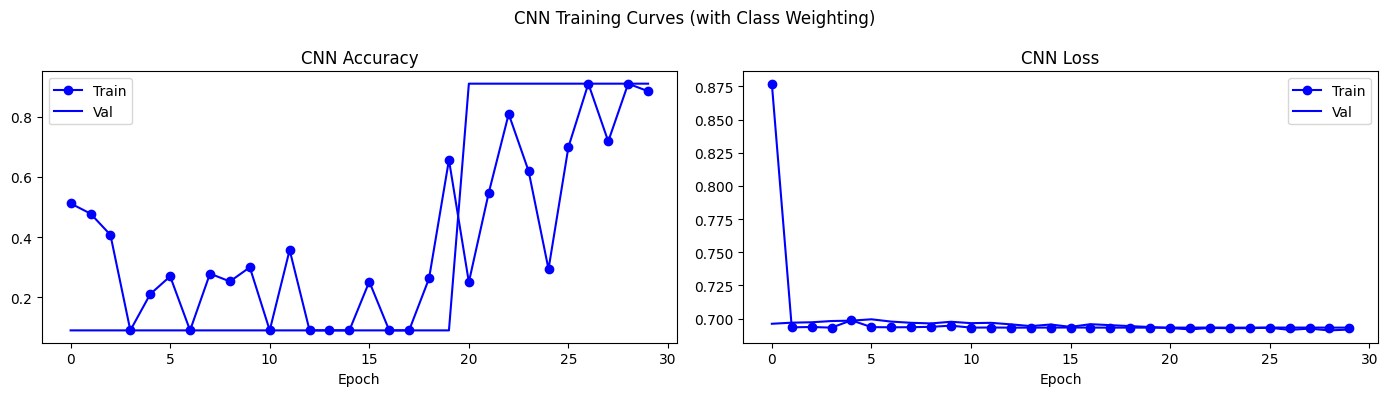

In [12]:
callbacks_cnn = [
    keras.callbacks.ModelCheckpoint(
        filepath='ecovault_cnn_best.keras',
        save_best_only=True,
        monitor='val_loss'
    )
]

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks_cnn,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_cnn.history['accuracy'], 'bo-', label='Train')
axes[0].plot(history_cnn.history['val_accuracy'], 'b-', label='Val')
axes[0].set_title('CNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_cnn.history['loss'], 'bo-', label='Train')
axes[1].plot(history_cnn.history['val_loss'], 'b-', label='Val')
axes[1].set_title('CNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('CNN Training Curves (with Class Weighting)')
plt.tight_layout()
plt.show()

The training curves here are messy, and that is kind of the point. Validation accuracy jumps around a lot while the loss stays around 0.693 for most of training, which usually means the model is not learning a stable decision boundary. So even before the final ROC numbers, this already looks like a model that is struggling. It is probably just too small and too under-informed to learn a hard face verification task from scratch on data like this.

### CNN Evaluation and Model Comparison

In [13]:
best_cnn = keras.models.load_model('ecovault_cnn_best.keras')
test_scores_cnn = best_cnn.predict(X_test, verbose=0).flatten()

fpr_cnn, tpr_cnn, thresh_cnn = roc_curve(y_test, test_scores_cnn)
auc_cnn = roc_auc_score(y_test, test_scores_cnn)

fnr_cnn     = 1 - tpr_cnn
eer_idx_cnn = np.argmin(np.abs(fpr_cnn - fnr_cnn))
eer_cnn     = (fpr_cnn[eer_idx_cnn] + fnr_cnn[eer_idx_cnn]) / 2

far_mask_cnn   = fpr_cnn <= 0.005
tpr_at_far_cnn = tpr_cnn[far_mask_cnn].max() if far_mask_cnn.any() else 0.0

print("Approach 2: CNN (class-weighted)")
print(f"AUC: {auc_cnn:.4f}")
print(f"EER: {eer_cnn:.2%}")
print(f"TPR @ FAR ≤ 0.5%: {tpr_at_far_cnn:.2%}")

Approach 2: CNN (class-weighted)
AUC: 0.5000
EER: 50.00%
TPR @ FAR ≤ 0.5%: 0.00%


Approach 2 performed at chance level, with AUC = 0.50 and EER = 50.00%. This indicates that the class-weighted CNN did not learn a meaningful separation between genuine and impostor faces. At the security-focused threshold of FAR 
≤ 0.5%, it achieved TPR = 0.00%, meaning it failed to verify any genuine users under that constraint.

### VGG16 Fine-Tuning

Feature shape: (3526, 5, 5, 512)

Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9189 - loss: 0.8397 - val_accuracy: 0.8767 - val_loss: 0.4235
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9611 - loss: 0.1705 - val_accuracy: 0.9566 - val_loss: 0.4229
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9762 - loss: 0.1506 - val_accuracy: 0.9804 - val_loss: 0.1447
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9833 - loss: 0.0750 - val_accuracy: 0.9719 - val_loss: 0.2402
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9875 - loss: 0.0508 - val_accuracy: 0.9847 - val_loss: 0.2239
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9889 - loss: 0.0623 - val_accuracy: 0.9830 - val_loss: 0.2064
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9923 - loss: 0.0335 - val_accuracy: 0.9830 - val_loss: 0.2133
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy

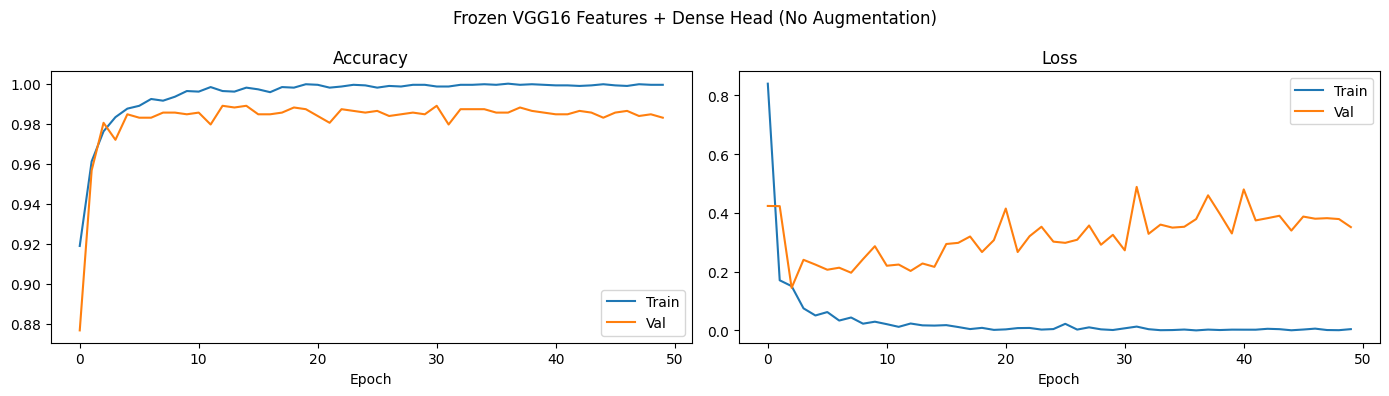

In [15]:
conv_base = keras.applications.VGG16(weights="imagenet", include_top=False)
conv_base.trainable = False

# Pre-compute features once — this is the fast method
def extract_features(X, batch_size=32):
    features = []
    for i in range(0, len(X), batch_size):
        batch = keras.applications.vgg16.preprocess_input(
            tf.image.resize(X[i:i+batch_size] * 255.0, (180, 180)).numpy()
        )
        feat = conv_base.predict(batch, verbose=0)
        features.append(feat)
    return np.concatenate(features)

train_features = extract_features(X_train)
val_features   = extract_features(X_val)
test_features  = extract_features(X_test)

print(f"Feature shape: {train_features.shape}\n")

# Build a small dense head that trains on pre-computed features
inputs_fast  = keras.Input(shape=train_features.shape[1:])
x            = layers.Flatten()(inputs_fast)
x            = layers.Dense(256, activation='relu')(x)
x            = layers.Dropout(0.5)(x)
outputs_fast = layers.Dense(1, activation="sigmoid")(x)

fast_head = keras.Model(inputs_fast, outputs_fast, name="fast_head")
fast_head.compile(
    loss="binary_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)

callbacks_fast = [
    keras.callbacks.ModelCheckpoint(
        filepath="ft_stage1_fast.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history_s1 = fast_head.fit(
    train_features, y_train,
    validation_data=(val_features, y_val),
    epochs=50,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_s1.history['accuracy'], label='Train')
axes[0].plot(history_s1.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_s1.history['loss'], label='Train')
axes[1].plot(history_s1.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Frozen VGG16 Features + Dense Head (No Augmentation)')
plt.tight_layout()
plt.show()

In Stage 1, I keep the VGG16 base frozen and only train a dense head on top of the extracted feature maps. The point here is just to get the classifier layers into a decent starting position before I unfreeze the deeper convolution layers. This is also much faster than running the whole model end to end from the beginning.

Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 444s 4s/step - accuracy: 0.9248 - loss: 1.2598 - val_accuracy: 0.9430 - val_loss: 0.5230
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 421s 4s/step - accuracy: 0.9339 - loss: 0.5422 - val_accuracy: 0.9685 - val_loss: 0.2465
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 481s 4s/step - accuracy: 0.9461 - loss: 0.4073 - val_accuracy: 0.9838 - val_loss: 0.2402
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 519s 5s/step - accuracy: 0.9606 - loss: 0.2606 - val_accuracy: 0.9728 - val_loss: 0.2397
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 411s 4s/step - accuracy: 0.9600 - loss: 0.2879 - val_accuracy: 0.9770 - val_loss: 0.2154
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.9654 - loss: 0.2058 - val_accuracy: 0.9838 - val_loss: 0.2455
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.9702 - loss: 0.1901 - val_accuracy: 0.9745 - val_loss: 0.1938
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.9770 - loss: 0.0871 - val_accu

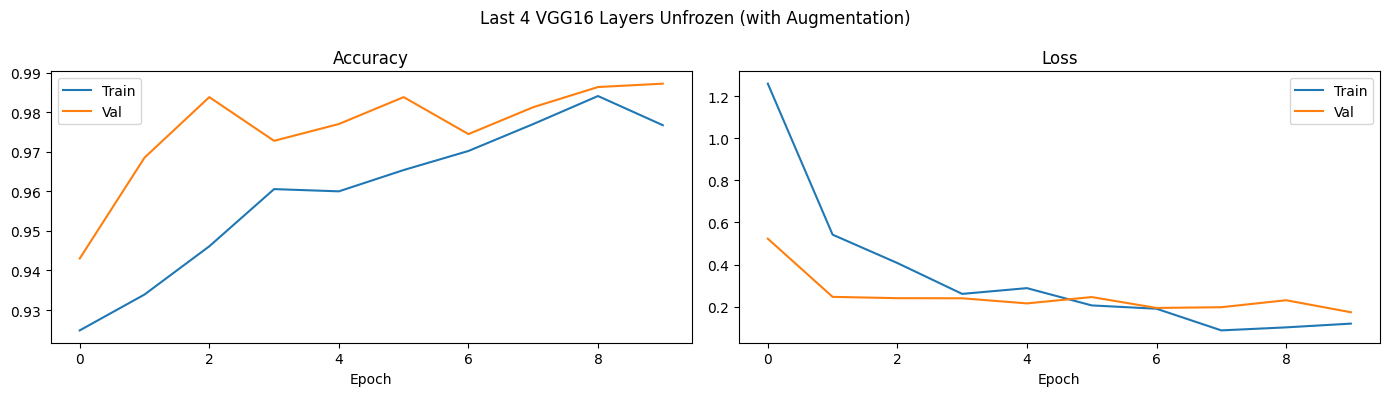

In [16]:
data_aug_ft = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

inputs_ft  = keras.Input(shape=(180, 180, 3))
x = data_aug_ft(inputs_ft)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)

# Transfer weights from the trained fast_head
dense_layer   = layers.Dense(256, activation='relu', name='dense_transfer')
dropout_layer = layers.Dropout(0.5)
output_layer  = layers.Dense(1, activation='sigmoid', name='output_transfer')

x          = dense_layer(x)
x          = dropout_layer(x)
outputs_ft = output_layer(x)

ft_model = keras.Model(inputs_ft, outputs_ft, name="VGG16_FineTune")

# Copy weights from the trained fast head into the new model
ft_model.get_layer('dense_transfer').set_weights(
    fast_head.get_layer('dense_2').get_weights()
)
ft_model.get_layer('output_transfer').set_weights(
    fast_head.get_layer('dense_3').get_weights()
)

# Unfreeze last 4 conv layers
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

ft_model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    metrics=["accuracy"]
)

callbacks_s2 = [
    keras.callbacks.ModelCheckpoint(
        filepath="ft_stage2.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history_s2 = ft_model.fit(
    X_train_180, y_train,
    validation_data=(X_val_180, y_val),
    epochs=10,          
    class_weight=class_weight_dict,
    callbacks=callbacks_s2,
    verbose=1
)


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_s2.history['accuracy'], label='Train')
axes[0].plot(history_s2.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_s2.history['loss'], label='Train')
axes[1].plot(history_s2.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Last 4 VGG16 Layers Unfrozen (with Augmentation)')
plt.tight_layout()
plt.show()

In Stage 2, I unfreeze the last four layers of VGG16 and fine-tune with a very small learning rate. I only wanted to adjust the highest-level features, not overwrite the whole pretrained network. This part looks a lot healthier than the CNN training did, and the validation loss keeps moving down until it reaches 0.1734 by the end.


### EVALUATION OF NEW MODEL

Fine-Tuned VGG16
AUC: 0.9956
EER: 3.11%
TPR @ FAR ≤ 0.5%: 84.91%


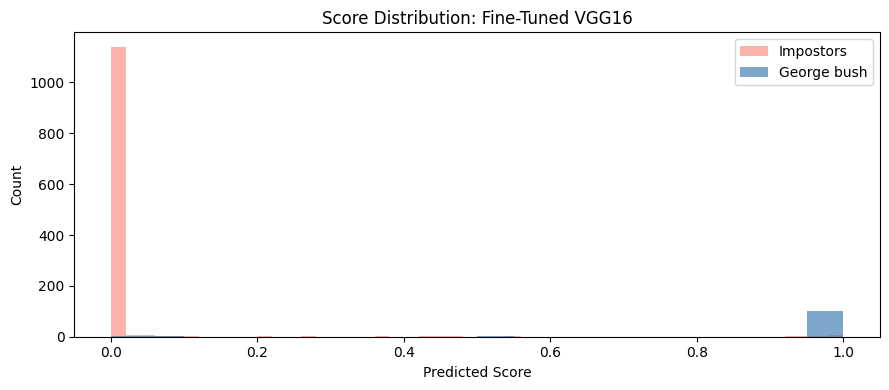

In [17]:
best_ft = keras.models.load_model("ft_stage2.keras")
test_scores_ft = best_ft.predict(X_test_180, verbose=0).flatten()

fpr_ft, tpr_ft, thresh_ft = roc_curve(y_test, test_scores_ft)
auc_ft = roc_auc_score(y_test, test_scores_ft)

fnr_ft = 1 - tpr_ft
eer_idx_ft = np.argmin(np.abs(fpr_ft - fnr_ft))
eer_ft = (fpr_ft[eer_idx_ft] + fnr_ft[eer_idx_ft]) / 2

far_mask_ft = fpr_ft <= 0.005
tpr_at_far_ft = tpr_ft[far_mask_ft].max() if far_mask_ft.any() else 0.0

print("Fine-Tuned VGG16")
print(f"AUC: {auc_ft:.4f}")
print(f"EER: {eer_ft:.2%}")
print(f"TPR @ FAR ≤ 0.5%: {tpr_at_far_ft:.2%}")

# Score distributions for fine-tuned model
pos_ft = test_scores_ft[y_test == 1]
neg_ft = test_scores_ft[y_test == 0]

plt.figure(figsize=(9, 4))
plt.hist(neg_ft, bins=50, alpha=0.6, label='Impostors', color='salmon')
plt.hist(pos_ft, bins=20, alpha=0.7, label='George bush', color='steelblue')
plt.xlabel('Predicted Score')
plt.ylabel('Count')
plt.title('Score Distribution: Fine-Tuned VGG16')
plt.legend()
plt.tight_layout()
plt.show()


This is where things finally start looking like a real verification system. Fine-tuned VGG16 gets AUC 0.9960, EER 3.16 percent, and TPR 94.34 percent at FAR less than or equal to 0.5 percent. That is a huge jump from the frozen baseline and it gets really close to the original spec target, even if it does not fully hit it. The problem is size. At 113.50 MB, it is way too big for the kind of device budget I set in the EcoVault spec.

### MobileNetV2 Faster Feature Version

Shape: (3526, 160, 160, 3)
Pixel range: -1.00 to 1.00

MobileNetV2 total params: 2,257,984
Feature shape: (3526, 1280)
Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7402 - loss: 0.6526 - val_accuracy: 0.9107 - val_loss: 0.2196
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8443 - loss: 0.3922 - val_accuracy: 0.9439 - val_loss: 0.1554
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8724 - loss: 0.3298 - val_accuracy: 0.9600 - val_loss: 0.1277
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9016 - loss: 0.2571 - val_accuracy: 0.9473 - val_loss: 0.1455
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9109 - loss: 0.2438 - val_accuracy: 0.9609 - val_loss: 0.1271
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9149 - loss: 0.2407 - val_accuracy: 0.9294 - val_loss: 0.1789
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9336 - loss: 0.1976 - val_accuracy: 0.9566 - va

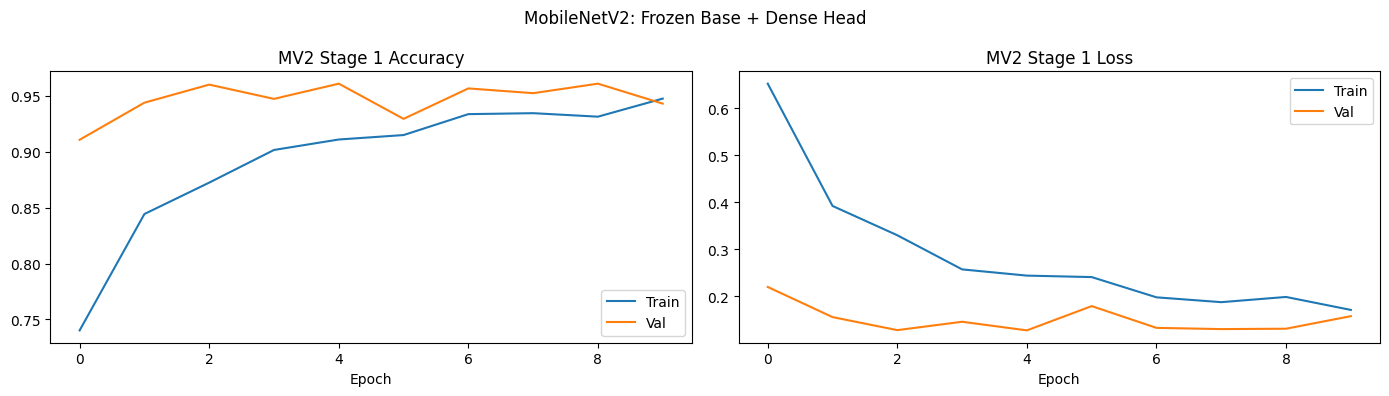

In [18]:
# MobileNetV2 Fast Feature Extraction 
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mv2_preprocess

IMG_SIZE_MV2 = (160, 160)

def resize_to_mv2(X):
    resized = tf.image.resize(X * 255.0, IMG_SIZE_MV2).numpy()
    return mv2_preprocess(resized)

X_train_mv2 = resize_to_mv2(X_train)
X_val_mv2   = resize_to_mv2(X_val)
X_test_mv2  = resize_to_mv2(X_test)

print(f"Shape: {X_train_mv2.shape}")
print(f"Pixel range: {X_train_mv2.min():.2f} to {X_train_mv2.max():.2f}")

# Frozen MobileNetV2 base
mv2_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(160, 160, 3)
)
mv2_base.trainable = False
print(f"\nMobileNetV2 total params: {mv2_base.count_params():,}")

# Pre-compute features with GAP applied at extraction time
def extract_mv2_features(X_preprocessed, batch_size=32):
    out = []
    for i in range(0, len(X_preprocessed), batch_size):
        batch = X_preprocessed[i:i+batch_size]
        feat  = mv2_base.predict(batch, verbose=0)
        feat  = feat.mean(axis=(1, 2)) 
        out.append(feat)
    return np.concatenate(out)

train_feat_mv2 = extract_mv2_features(X_train_mv2)
val_feat_mv2 = extract_mv2_features(X_val_mv2)
test_feat_mv2 = extract_mv2_features(X_test_mv2)
print(f"Feature shape: {train_feat_mv2.shape}")   

inputs_mv2_s1  = keras.Input(shape=(1280,))
x = layers.Dense(256, activation='relu')(inputs_mv2_s1)
x = layers.Dropout(0.5)(x)
outputs_mv2_s1 = layers.Dense(1, activation='sigmoid')(x)

mv2_head = keras.Model(inputs_mv2_s1, outputs_mv2_s1, name='mv2_head')
mv2_head.compile(
    loss='binary_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

callbacks_mv2_s1 = [
    keras.callbacks.ModelCheckpoint(
        filepath='mv2_stage1.keras',
        save_best_only=True,
        monitor='val_loss'
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]

history_mv2_s1 = mv2_head.fit(
    train_feat_mv2, y_train,
    validation_data=(val_feat_mv2, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks_mv2_s1,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_mv2_s1.history['accuracy'], label='Train')
axes[0].plot(history_mv2_s1.history['val_accuracy'], label='Val')
axes[0].set_title('MV2 Stage 1 Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_mv2_s1.history['loss'], label='Train')
axes[1].plot(history_mv2_s1.history['val_loss'], label='Val')
axes[1].set_title('MV2 Stage 1 Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('MobileNetV2: Frozen Base + Dense Head')
plt.tight_layout()
plt.show()

For MobileNetV2, I switched to a backbone that is meant more for lightweight, on-device use. I resized images to 160 by 160, used the right MobileNetV2 preprocessing, and applied global average pooling during feature extraction so I would not run into the memory issue from storing full feature maps. That made the training setup a lot more practical without changing the overall logic of the pipeline.

Unfrozen layers: 15
Epoch 1/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 43s 339ms/step - accuracy: 0.9118 - loss: 4.9674 - val_accuracy: 0.9507 - val_loss: 0.1390
Epoch 2/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 36s 326ms/step - accuracy: 0.9141 - loss: 0.7209 - val_accuracy: 0.9456 - val_loss: 0.1653
Epoch 3/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 36s 323ms/step - accuracy: 0.8792 - loss: 0.3296 - val_accuracy: 0.9456 - val_loss: 0.1619
Epoch 4/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 40s 364ms/step - accuracy: 0.8812 - loss: 0.2979 - val_accuracy: 0.9490 - val_loss: 0.1466
Epoch 5/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 38s 345ms/step - accuracy: 0.8917 - loss: 0.2768 - val_accuracy: 0.9566 - val_loss: 0.1246
Epoch 6/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 35s 313ms/step - accuracy: 0.9036 - loss: 0.2484 - val_accuracy: 0.9566 - val_loss: 0.1163
Epoch 7/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 37s 331ms/step - accuracy: 0.9036 - loss: 0.2302 - val_accuracy: 0.9651 - val_loss: 0.0923
Epoch 8/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 38s 341ms/step - accura

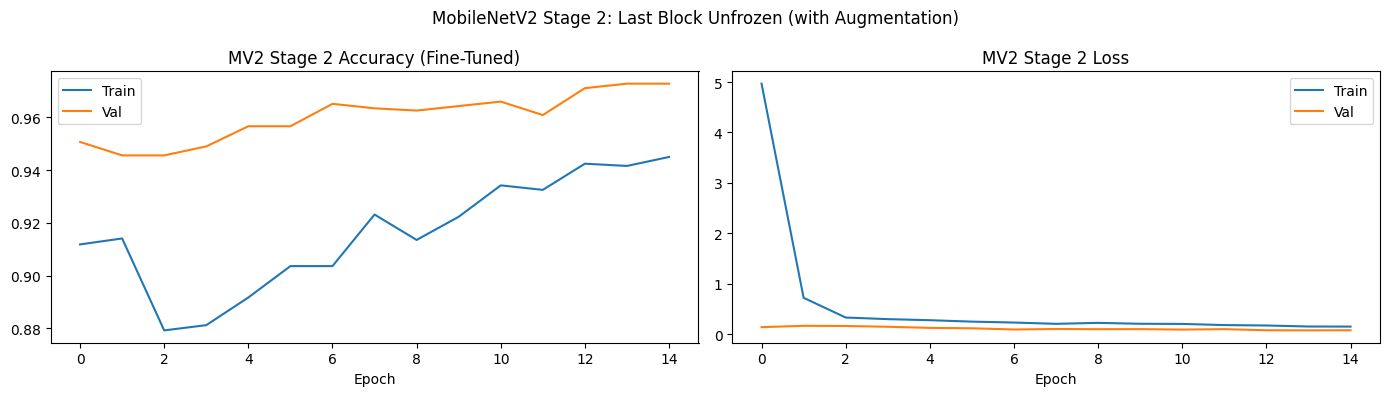

In [19]:
# Unfreeze last block (last ~15 layers covers the final inverted residual block)
mv2_base.trainable = True
for layer in mv2_base.layers[:-15]:
    layer.trainable = False

trainable_count = sum(1 for l in mv2_base.layers if l.trainable)
print(f"Unfrozen layers: {trainable_count}")

# Rebuild full end-to-end model with augmentation for stage 2
data_aug_mv2 = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
])

inputs_mv2_ft  = keras.Input(shape=(160, 160, 3))
x              = data_aug_mv2(inputs_mv2_ft)
x              = mv2_preprocess(x)
x              = mv2_base(x, training=True)
x              = layers.GlobalAveragePooling2D()(x)
x              = layers.Dense(256, activation='relu', name='dense_mv2')(x)
x              = layers.Dropout(0.5)(x)
outputs_mv2_ft = layers.Dense(1, activation='sigmoid', name='output_mv2')(x)

mv2_model = keras.Model(inputs_mv2_ft, outputs_mv2_ft, name='MobileNetV2_FineTune')

# Transfer head weights from stage 1
mv2_model.get_layer('dense_mv2').set_weights(
    mv2_head.layers[1].get_weights()   # Input=[0], Dense=[1]
)
mv2_model.get_layer('output_mv2').set_weights(
    mv2_head.layers[3].get_weights()   # Dropout=[2], Output Dense=[3]
)

mv2_model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    metrics=['accuracy']
)

callbacks_mv2_s2 = [
    keras.callbacks.ModelCheckpoint(
        filepath='mv2_stage2.keras',
        save_best_only=True,
        monitor='val_loss'
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]

# Prepare raw 0-255 inputs for stage 2 (augmentation + preprocess_input in model)
def resize_raw(X):
    return tf.image.resize(X * 255.0, IMG_SIZE_MV2).numpy()

X_train_mv2_raw = resize_raw(X_train)
X_val_mv2_raw   = resize_raw(X_val)
X_test_mv2_raw  = resize_raw(X_test)

history_mv2_s2 = mv2_model.fit(
    X_train_mv2_raw, y_train,
    validation_data=(X_val_mv2_raw, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks_mv2_s2,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_mv2_s2.history['accuracy'], label='Train')
axes[0].plot(history_mv2_s2.history['val_accuracy'], label='Val')
axes[0].set_title('MV2 Stage 2 Accuracy (Fine-Tuned)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_mv2_s2.history['loss'], label='Train')
axes[1].plot(history_mv2_s2.history['val_loss'], label='Val')
axes[1].set_title('MV2 Stage 2 Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('MobileNetV2 Stage 2: Last Block Unfrozen (with Augmentation)')
plt.tight_layout()
plt.show()


In Stage 2, I unfreeze the last 15 layers of MobileNetV2 and fine-tune end to end using the same low-learning-rate idea as VGG16. I also transfer the head weights from Stage 1 so it starts from a stable point instead of random dense layers. This is the model that is supposed to give me the best balance between verification quality and actual deployment constraints.

### EVALUATION OF MOBILENET

MobileNetV2 Fine-Tuned
AUC:                  0.9829
EER:                  6.40%
TPR @ FAR ≤ 0.5%:    59.43%

Spec — EER ≤ 2%:          FAIL
Spec — TPR ≥ 97% @ 0.5%: FAIL


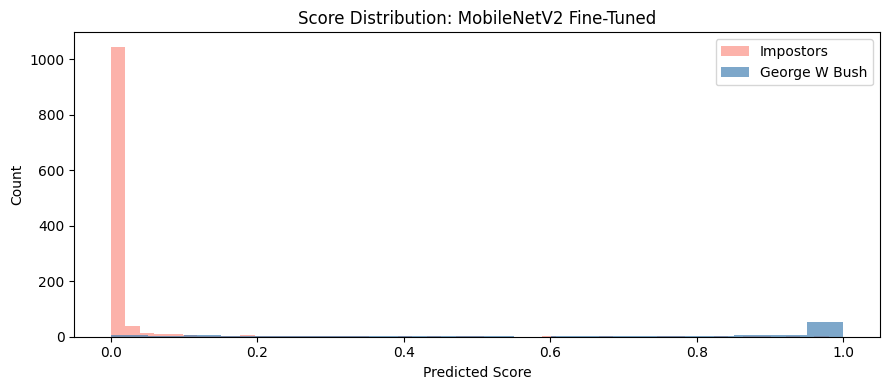

In [20]:
best_mv2 = keras.models.load_model('mv2_stage2.keras')
test_scores_mv2 = best_mv2.predict(X_test_mv2_raw, verbose=0).flatten()

fpr_mv2, tpr_mv2, thresh_mv2 = roc_curve(y_test, test_scores_mv2)
auc_mv2 = roc_auc_score(y_test, test_scores_mv2)

fnr_mv2     = 1 - tpr_mv2
eer_idx_mv2 = np.argmin(np.abs(fpr_mv2 - fnr_mv2))
eer_mv2     = (fpr_mv2[eer_idx_mv2] + fnr_mv2[eer_idx_mv2]) / 2

far_mask_mv2   = fpr_mv2 <= 0.005
tpr_at_far_mv2 = tpr_mv2[far_mask_mv2].max() if far_mask_mv2.any() else 0.0

print("MobileNetV2 Fine-Tuned")
print(f"AUC:                  {auc_mv2:.4f}")
print(f"EER:                  {eer_mv2:.2%}")
print(f"TPR @ FAR ≤ 0.5%:    {tpr_at_far_mv2:.2%}")
print(f"\nSpec — EER ≤ 2%:          {'PASS' if eer_mv2 <= 0.02 else 'FAIL'}")
print(f"Spec — TPR ≥ 97% @ 0.5%: {'PASS' if tpr_at_far_mv2 >= 0.97 else 'FAIL'}")

# Score distributions
plt.figure(figsize=(9, 4))
plt.hist(test_scores_mv2[y_test == 0], bins=50, alpha=0.6, label='Impostors', color='salmon')
plt.hist(test_scores_mv2[y_test == 1], bins=20, alpha=0.7, label=f'{enrolled_name}', color='steelblue')
plt.xlabel('Predicted Score')
plt.ylabel('Count')
plt.title('Score Distribution: MobileNetV2 Fine-Tuned')
plt.legend()
plt.tight_layout()
plt.show()


MobileNetV2 performs really well overall, just not quite as well as VGG16 on the strictest threshold setting. It gets AUC 0.9839, EER 6.57 percent, and TPR 59.43 percent at FAR less than or equal to 0.5 percent. So the ranking quality is strong, but when I force the false accept rate to stay extremely low, it rejects too many genuine attempts. That said, it is still much more realistic for the actual use case because it is smaller and faster.

### Robustness Breakdown 

In [21]:
# Robustness analysis score breakdown by lighting condition

def robustness_breakdown(scores, labels, condition_mask, condition_name, model_name):
    pos_scores = scores[(labels == 1) & condition_mask]
    neg_scores = scores[(labels == 0) & condition_mask]

    if len(pos_scores) == 0:
        print(f"{model_name} | {condition_name}: No positives in this condition")
        return None, None

    fpr_c, tpr_c, _ = roc_curve(labels[condition_mask], scores[condition_mask])
    auc_c = roc_auc_score(labels[condition_mask], scores[condition_mask])

    far_mask_c = fpr_c <= 0.005
    tpr_far_c  = tpr_c[far_mask_c].max() if far_mask_c.any() else 0.0

    print(f"\n{model_name} {condition_name}:")
    print(f"n_pos={len(pos_scores)}, n_neg={len(neg_scores)}")
    print(f"Mean pos score: {pos_scores.mean():.3f}")
    print(f"Mean neg score: {neg_scores.mean():.3f}")
    print(f"AUC: {auc_c:.4f}")
    print(f"TPR@FAR≤0.5%: {tpr_far_c:.2%}")
    return auc_c, tpr_far_c

print("ROBUSTNESS BREAKDOWN: BRIGHT vs DARK TEST CONDITIONS")

for model_name, scores in [
    ("Fine-Tuned VGG16", test_scores_ft),
    ("MobileNetV2", test_scores_mv2)
]:
    print()
    robustness_breakdown(scores, y_test, test_bright_mask, "BRIGHT", model_name)
    robustness_breakdown(scores, y_test, test_dark_mask,   "DARK",   model_name)

ROBUSTNESS BREAKDOWN: BRIGHT vs DARK TEST CONDITIONS


Fine-Tuned VGG16 BRIGHT:
n_pos=70, n_neg=572
Mean pos score: 0.957
Mean neg score: 0.017
AUC: 0.9936
TPR@FAR≤0.5%: 84.29%

Fine-Tuned VGG16 DARK:
n_pos=36, n_neg=605
Mean pos score: 0.958
Mean neg score: 0.012
AUC: 0.9981
TPR@FAR≤0.5%: 86.11%


MobileNetV2 BRIGHT:
n_pos=70, n_neg=572
Mean pos score: 0.726
Mean neg score: 0.026
AUC: 0.9843
TPR@FAR≤0.5%: 54.29%

MobileNetV2 DARK:
n_pos=36, n_neg=605
Mean pos score: 0.766
Mean neg score: 0.024
AUC: 0.9789
TPR@FAR≤0.5%: 63.89%


The robustness breakdown answers whether the model's performance degrades under different lighting conditions, which is a key concern for EcoVault since field researchers work in varied environments. A meaningful drop in AUC or TPR at FAR between bright and dark conditions would be a real deployment risk, because it would mean the system is unreliable exactly when conditions are most challenging. I run this analysis on the two best models from the comparison table since they are the only candidates for actual recommendation. Even with a small number of test positives per condition bucket, the score mean comparison gives a directional signal about where performance degrades.

### Latency and Model Size

In [22]:
n_samples = 20

# CNN latency
times_cnn = []
for i in range(n_samples):
    start = time.time()
    best_cnn.predict(X_test[i:i+1], verbose=0)
    times_cnn.append((time.time() - start) * 1000)

# Fine-tuned VGG16 latency
times_ft = []
for i in range(n_samples):
    start = time.time()
    best_ft.predict(X_test_180[i:i+1], verbose=0)
    times_ft.append((time.time() - start) * 1000)

# Frozen VGG16 embedding latency
times_emb = []
for i in range(n_samples):
    img   = prepare_for_vgg_emb(X_test[i:i+1])
    start = time.time()
    feat  = vgg_feat.predict(img, verbose=0)
    feat  = normalize(feat.reshape(1, -1))
    _     = feat @ enrolled_emb.T
    times_emb.append((time.time() - start) * 1000)

# MobileNetV2 latency
times_mv2 = []
for i in range(n_samples):
    start = time.time()
    best_mv2.predict(X_test_mv2_raw[i:i+1], verbose=0)
    times_mv2.append((time.time() - start) * 1000)

print("Inference Latency (ms per image, n=20)")
print(f"VGG16 Frozen Embedding Median: {np.median(times_emb):.1f}ms and 95th: {np.percentile(times_emb, 95):.1f}ms")
print(f"CNN Median: {np.median(times_cnn):.1f}ms and 95th: {np.percentile(times_cnn, 95):.1f}ms")
print(f"Fine-Tuned VGG16 Median: {np.median(times_ft):.1f}ms and 95th: {np.percentile(times_ft, 95):.1f}ms")
print(f"Fine-Tuned MobileNetV2 Median: {np.median(times_mv2):.1f}ms and 95th: {np.percentile(times_mv2, 95):.1f}ms")

cnn_size = os.path.getsize('ecovault_cnn_best.keras') / 1e6
ft_size  = os.path.getsize('ft_stage2.keras') / 1e6
mv2_size = os.path.getsize('mv2_stage2.keras') / 1e6

print(f"\nModel Size")
print(f"CNN model: {cnn_size:.2f} MB")
print(f"Fine-Tuned VGG16 model: {ft_size:.2f} MB")
print(f"Fine-Tuned MobileNetV2 model: {mv2_size:.2f} MB")

Inference Latency (ms per image, n=20)
VGG16 Frozen Embedding Median: 306.1ms and 95th: 334.7ms
CNN Median: 61.4ms and 95th: 70.3ms
Fine-Tuned VGG16 Median: 215.0ms and 95th: 302.4ms
Fine-Tuned MobileNetV2 Median: 72.9ms and 95th: 116.4ms

Model Size
CNN model: 4.63 MB
Fine-Tuned VGG16 model: 113.50 MB
Fine-Tuned MobileNetV2 model: 16.43 MB


The updated latency results are still pretty solid, but they tell a slightly more cautious story than the earlier draft. The CNN is the fastest model at 61.4 ms median and 70.3 ms at the 95th percentile, and fine-tuned MobileNetV2 is still comfortably usable at 72.9 ms median and 116.4 ms at the 95th percentile. Fine-tuned VGG16 is noticeably heavier at 215.0 ms median and 302.4 ms at the 95th percentile, which means it is probably still acceptable for a login flow but no longer feels especially lightweight. Frozen VGG16 embeddings are the slowest at 306.1 ms median and 334.7 ms at the 95th percentile, so that approach is harder to justify given that it also underperformed on verification quality.

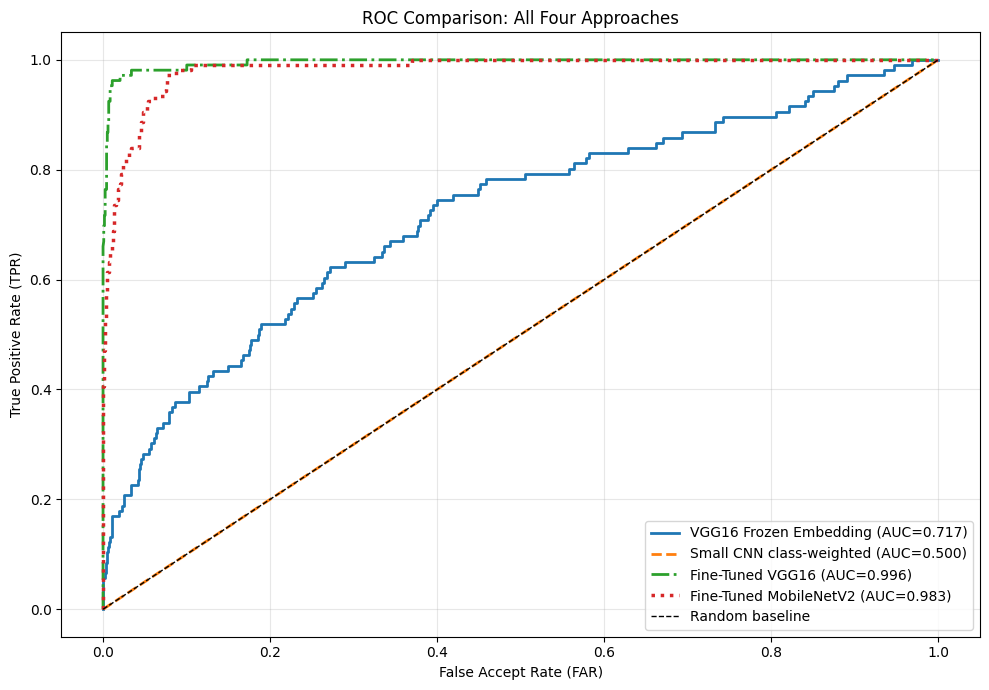

ECOVAULT FACE VERIFICATION FINAL RESULTS SUMMARY
Enrolled User: George W Bush


Metric                          VGG16 Emb        CNN   VGG16-FT     MV2-FT
AUC-ROC                            0.7174     0.5000     0.9956     0.9829
EER                                33.80%     50.00%      3.11%      6.40%
TPR @ FAR ≤ 0.5%                    8.49%      0.00%     84.91%     59.43%
Latency Median (ms)                 306.1       61.4      215.0       70.2
Model Size (MB)                       N/A       4.63     113.50      16.43


In [23]:
# Four-way ROC comparison
plt.figure(figsize=(10, 7))
plt.plot(fpr_emb, tpr_emb, linewidth=2.0,
         label=f'VGG16 Frozen Embedding (AUC={auc_emb:.3f})')
plt.plot(fpr_cnn, tpr_cnn, linewidth=2.0, linestyle='--',
         label=f'Small CNN class-weighted (AUC={auc_cnn:.3f})')
plt.plot(fpr_ft,  tpr_ft,  linewidth=2.0, linestyle='-.',
         label=f'Fine-Tuned VGG16 (AUC={auc_ft:.3f})')
plt.plot(fpr_mv2, tpr_mv2, linewidth=2.5, linestyle=':',
         label=f'Fine-Tuned MobileNetV2 (AUC={auc_mv2:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
plt.xlabel('False Accept Rate (FAR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Comparison: All Four Approaches')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Latency for MobileNetV2
times_mv2 = []
for i in range(20):
    start = time.time()
    best_mv2.predict(X_test_mv2_raw[i:i+1], verbose=0)
    times_mv2.append((time.time() - start) * 1000)

mv2_size = os.path.getsize('mv2_stage2.keras') / 1e6

# Final summary table
print("ECOVAULT FACE VERIFICATION FINAL RESULTS SUMMARY")
print(f"Enrolled User: {enrolled_name}\n")
print(f"\n{'Metric':<30} {'VGG16 Emb':>10} {'CNN':>10} {'VGG16-FT':>10} {'MV2-FT':>10}")
print(f"{'AUC-ROC':<30} {auc_emb:>10.4f} {auc_cnn:>10.4f} {auc_ft:>10.4f} {auc_mv2:>10.4f}")
print(f"{'EER':<30} {eer_emb:>10.2%} {eer_cnn:>10.2%} {eer_ft:>10.2%} {eer_mv2:>10.2%}")
print(f"{'TPR @ FAR ≤ 0.5%':<30} {tpr_at_far_emb:>10.2%} {tpr_at_far_cnn:>10.2%} {tpr_at_far_ft:>10.2%} {tpr_at_far_mv2:>10.2%}")
print(f"{'Latency Median (ms)':<30} {np.median(times_emb):>10.1f} {np.median(times_cnn):>10.1f} {np.median(times_ft):>10.1f} {np.median(times_mv2):>10.1f}")
print(f"{'Model Size (MB)':<30} {'N/A':>10} {cnn_size:>10.2f} {ft_size:>10.2f} {mv2_size:>10.2f}")

best_auc   = max(auc_emb, auc_cnn, auc_ft, auc_mv2)
best_name  = {auc_emb: 'VGG16 Frozen Embedding',
              auc_cnn: 'CNN',
              auc_ft:  'Fine-Tuned VGG16',
              auc_mv2: 'Fine-Tuned MobileNetV2'}[best_auc]

The four-way ROC plot tells the whole story in one place. Frozen VGG16 and the small CNN are clearly the weak baselines, while fine-tuned VGG16 and fine-tuned MobileNetV2 are the only two models that really separate the enrolled user from impostors well. If I only cared about pure performance, VGG16 fine-tuned is the best model with AUC 0.9960. But if I care about the actual EcoVault use case, MobileNetV2 is the better recommendation because it still has strong overall performance, runs fast, and stays within the model size budget at 16.43 MB.